## <span style="color:grey"> <u>India Cancer Patient Dataset Analysis and Prediction(2022-2025)</span></u>


***➤ <span style="color:red">Cancer</span> is one of the major health challenges around the world, and identifying patients who are at <span style="color:red">higher risk</span> can help doctors provide timely care and closer monitoring.***

***➤ In this project, a machine learning approach was used to analyze patient characteristics such as <span style="color:blue">age, gender, cancer type, stage, treatment type, and other clinical factors </span> to predict whether a patient was at <span style="color:red"> higher risk of mortality</span>.***

***➤ Rather than focusing only on achieving the highest accuracy, my main goal was to identify patients who may be at greater risk.*** 

***➤ Missing a truly high-risk patient can have serious consequences, so I paid special attention to <span style="color:blue">evaluation metrics</span> that reflect this objective.***

***➤ Through this project, I explored different machine learning models, compared their performance, and looked for ways to make the predictions more useful in a healthcare setting.***

#### <u>Importing necessary libraries and Loading dataset</u>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\najee\Downloads\india_cancer_patients_2022_2025.csv")
df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


### <u>Data Exploration</u>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


### <u>Checking for null values</u>

In [4]:
df.isna().sum()

Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

***◆ The data is clean.it doesnt contain any null values***

In [5]:
df.describe()

,Age,Survival_Months
count,100000.000000,100000.000000
mean,53.899460,20.333353
std,13.653781,14.156450
min,1.000000,1.000000
25%,45.000000,8.200000
50%,54.000000,17.200000
75%,63.000000,30.600000
max,95.000000,53.300000


In [6]:
df.Status.value_counts()

Status
Deceased    63577
Alive       36423
Name: count, dtype: int64

***◆ The target variable exhibited a moderate class imbalance, with 63.6% of patients classified as deceased and 36.4% as alive.***

### <u>Cancer Cases Across Different Age Groups</u>

In [7]:
df.groupby("Age")["Status"].count().sort_values(ascending=False)

Age
55    3172
54    3110
56    3067
57    3012
53    2969
      ... 
4       32
2       27
5       26
93      26
6       24
Name: Status, Length: 95, dtype: int64

In [191]:
df["Age_Group"]= pd.cut(
    df["Age"],
    bins=[0,20,40,60,80,100],
    labels=["0-20", "20-40", "40-60", "60-80", "80+"]
)

In [212]:
age_pct= df["Age_Group"].value_counts(normalize=True).sort_index()*100
age_pct

Age_Group
0-20      1.414
20-40    13.760
40-60    53.095
60-80    29.801
80+       1.930
Name: proportion, dtype: float64

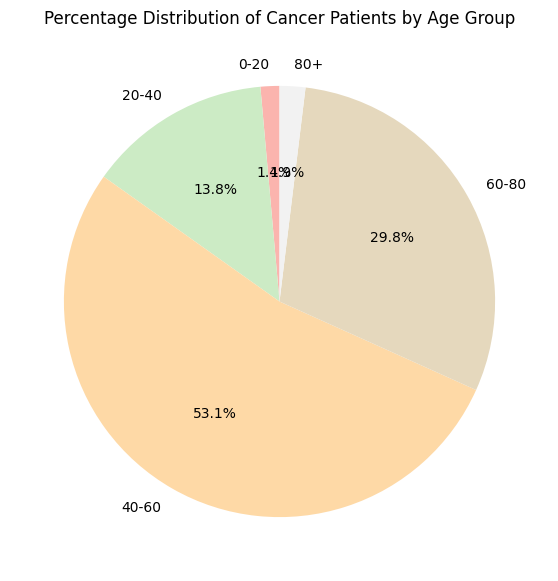

In [193]:
colors = plt.cm.Pastel1(np.linspace(0, 1, len(age_pct)))

plt.figure(figsize=(7, 7))

plt.pie(
    age_pct,
    labels=age_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Percentage Distribution of Cancer Patients by Age Group")
plt.show()


***<em> ◆ Most cancer patients are middle-aged to older adults
The 40–60 age group contributes (53.1%).
The 60–80 age group contributes another 29.8%.</em>***

***<em>◆ Together:
53.1%+29.8%=82.9%
So, about 83% of the patients are between 40 and 80 years old.</em>***

***<em>◆ Very few young patients
0–20 years: only 1.4%
20–40 years: 13.8%
cancer become more common with increasing age.</em>***

***<em>◆ Only 1.9% of patients are 80+.
may be The population has fewer people with age 80+
or the records of older people is less in the dataset
else dataset may come from specific hospitals or registries it doesnt represents the entire population. </em>***

In [71]:
status_pct=pd.crosstab(
    Age_Group,
    df["Status"],
    normalize="index"
) * 100 
status_pct

Status,Alive,Deceased
Age,,
0-20,38.401697,61.598303
20-40,40.784884,59.215116
40-60,36.890479,63.109521
60-80,33.673367,66.326633
80+,33.471503,66.528497


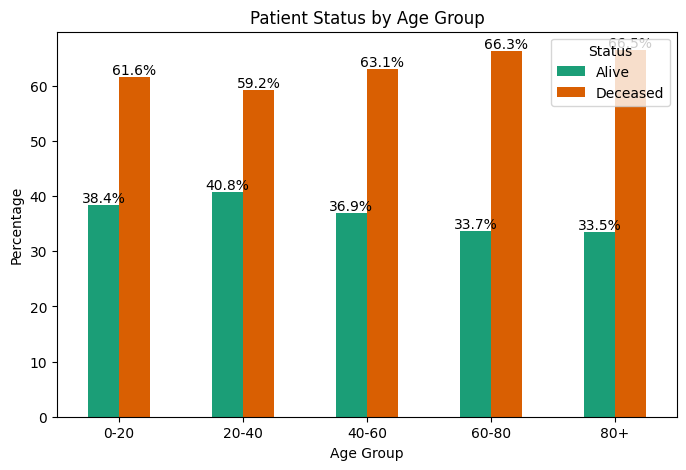

In [70]:
ax = status_pct.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("Age Group")
plt.title("Patient Status by Age Group")
plt.legend(title="Status")
plt.xticks(rotation=0)
plt.show()

***◆ from the stacked barplot it is clear that the percentage of deceased patients generally rises as age increases***

***◆ Older patients in this dataset have poor survival rate***

***◆ The 20–40 group has the highest survival rate (40.8%) and the lowest mortality rate (59.2%).***

***◆ This answers the question Is age an important predictor?***
    

### <u> Cancer Cases Across Gender</u>

In [74]:
status_pct_by_gender=pd.crosstab(df["Gender"]
   ,
    df["Status"],
    normalize="index"
) * 100 
status_pct_by_gender

Status,Alive,Deceased
Gender,,
Female,38.537028,61.462972
Male,32.101434,67.898566


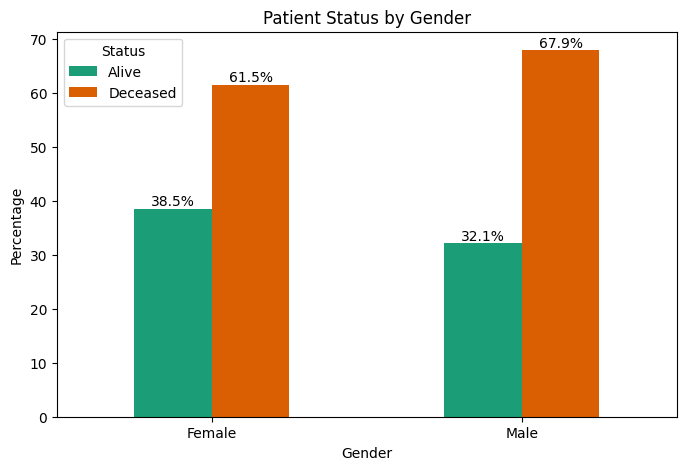

In [75]:
ax = status_pct_by_gender.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.title("Patient Status by Gender")
plt.legend(title="Status")
plt.xticks(rotation=0)
plt.show()

In [76]:
pd.crosstab(df["Gender"], df["Status"])

Status,Alive,Deceased
Gender,,
Female,25878,41273
Male,10545,22304


In [181]:
cancer_type_by_gender=pd.crosstab(df["Gender"], df["Cancer_Type"])
cancer_type_by_gender

Cancer_Type,Breast Cancer,Cervical Cancer,Colorectal Cancer,Leukemia,Lung Cancer,Oral Cancer,Ovarian Cancer,Prostate Cancer,Stomach Cancer
Gender,,,,,,,,,
Female,28169,13881,4053,2043,4749,6388,3908,0,3960
Male,0,0,3882,2027,7297,9871,0,5809,3963


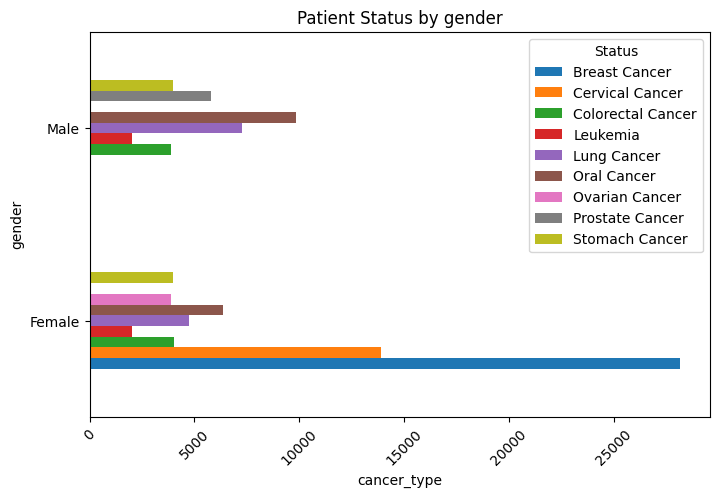

In [183]:
cancer_type_by_gender.plot(kind="barh", figsize=(8, 5),
   
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("gender")
plt.xlabel("cancer_type")
plt.title("Patient Status by gender")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ The data shows that male patients had a higher death rate than female patients. Roughly 6 out of 10 female patients were deceased, compared to nearly 7 out of 10 male patients. This indicates that female patients appeared to have better survival outcomes in this dataset.***

***◆ Since there were more female patients (67,151) than male patients (32,849) in the dataset, the percentages should be interpreted in the context of this difference in group sizes.***

***◆ Also Cancer Type showed a strong association with Gender. Breast, Cervical, and Ovarian cancers were observed among female patients, while Prostate Cancer occurred only among males. This suggests survival differences observed between males and females may be influenced by the distribution of cancer types across genders.***

***◆ Gender and Cancer Type are not independent features there's a strong relation between them.***

### <u>Analyzing Cancer Types and Patient Status</u>

In [83]:
status_pct_by_cancer_type=pd.crosstab(df["Cancer_Type"], df["Status"],normalize="index")
status_pct_by_cancer_type

Status,Alive,Deceased
Cancer_Type,,
Breast Cancer,0.477759,0.522241
Cervical Cancer,0.367913,0.632087
Colorectal Cancer,0.328922,0.671078
Leukemia,0.347666,0.652334
Lung Cancer,0.126183,0.873817
Oral Cancer,0.408020,0.591980
Ovarian Cancer,0.362078,0.637922
Prostate Cancer,0.518506,0.481494
Stomach Cancer,0.158021,0.841979


In [87]:
pd.crosstab(df["Cancer_Type"], df["Status"])

Status,Alive,Deceased
Cancer_Type,,
Breast Cancer,13458,14711
Cervical Cancer,5107,8774
Colorectal Cancer,2610,5325
Leukemia,1415,2655
Lung Cancer,1520,10526
Oral Cancer,6634,9625
Ovarian Cancer,1415,2493
Prostate Cancer,3012,2797
Stomach Cancer,1252,6671


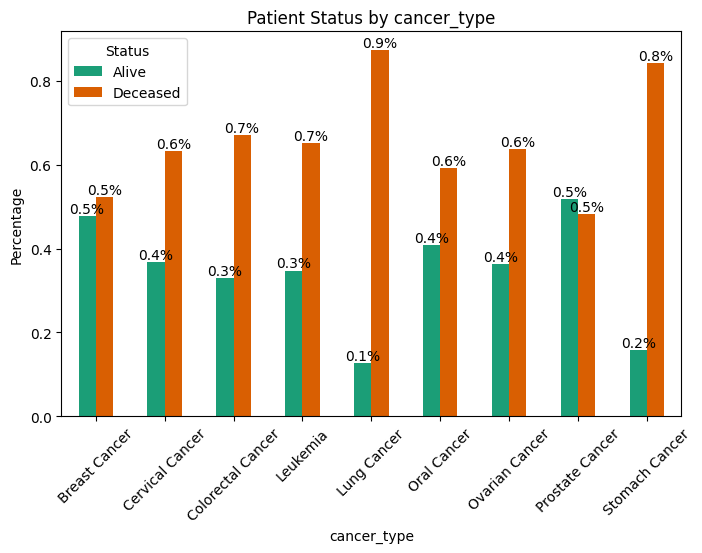

In [85]:
ax = status_pct_by_cancer_type.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("cancer_type")
plt.title("Patient Status by cancer_type")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ Prostate and Breast Cancer patients showed comparatively better survival rates,***

***◆ whereas Lung and Stomach Cancer patients had substantially higher mortality rates.***

***◆This suggests type of cancer is a strong predictor of survival status of patients in this dataset.***

### <u>Cancer Stage and Patient Outcome Analysis</u>

In [88]:
status_pct_by_cancer_stage=pd.crosstab(df["Stage"], df["Status"],normalize="index")
status_pct_by_cancer_stage

Status,Alive,Deceased
Stage,,
Stage I,0.634232,0.365768
Stage II,0.495926,0.504074
Stage III,0.316752,0.683248
Stage IV,0.135215,0.864785


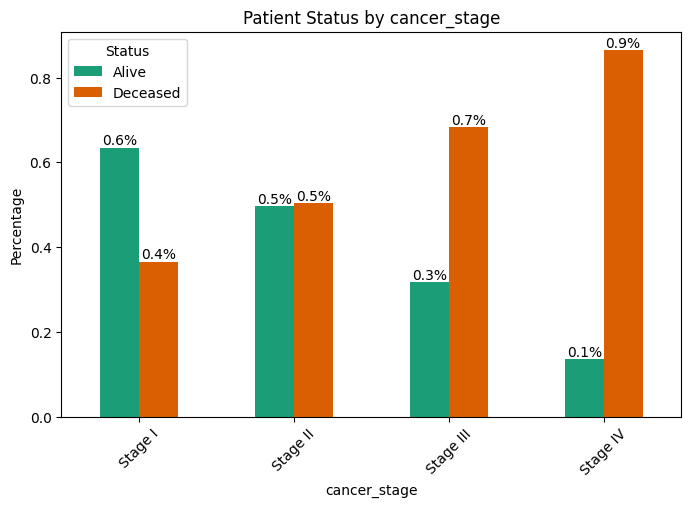

In [89]:
ax = status_pct_by_cancer_stage.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("cancer_stage")
plt.title("Patient Status by cancer_stage")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ From the graph it is evident that the patients diagnosed at earlier stages had much better survival rates, while those diagnosed at later stages had higher mortality rates.This suggests the cancer_stage is one of the stronger predictor of survival_status of patients***

### <u>Patient Status Breakdown by State</u>

In [90]:
status_pct_by_state=pd.crosstab(df["State"], df["Status"],normalize="index")
status_pct_by_state

Status,Alive,Deceased
State,,
Chandigarh,0.361298,0.638702
Delhi,0.362223,0.637777
Gujarat,0.361108,0.638892
Karnataka,0.366624,0.633376
Kerala,0.368694,0.631306
Maharashtra,0.361362,0.638638
Tamil Nadu,0.368611,0.631389
Telangana,0.367223,0.632777
West Bengal,0.362933,0.637067


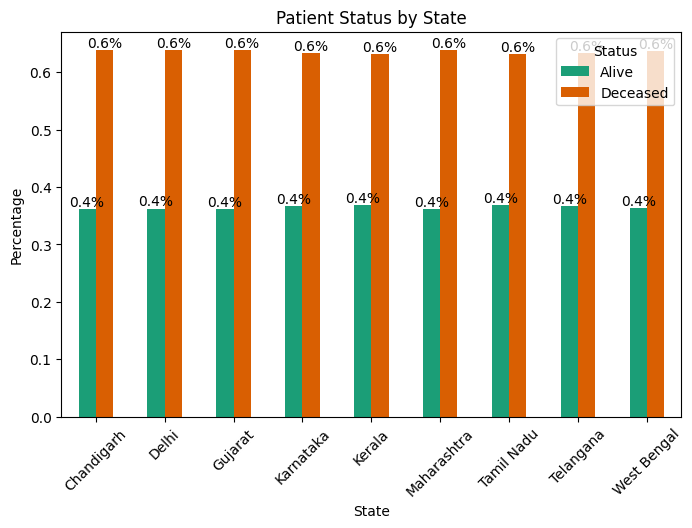

In [92]:
ax = status_pct_by_state.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("State")
plt.title("Patient Status by State")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ This shows survival status kind of uniform all around the state.which suggests weak relation of state for predicting survival status of cancer patients.may drop the column later since its a weak predictor***

### <u>Patient Status Breakdown by city</u>

In [91]:
status_pct_by_city=pd.crosstab(df["City"], df["Status"],normalize="index")
status_pct_by_city

Status,Alive,Deceased
City,,
Ahmedabad,0.361108,0.638892
Bengaluru,0.366624,0.633376
Chandigarh,0.361298,0.638702
Chennai,0.368611,0.631389
Hyderabad,0.367223,0.632777
Kolkata,0.362933,0.637067
Mumbai,0.361362,0.638638
New Delhi,0.362223,0.637777
Thiruvananthapuram,0.368694,0.631306


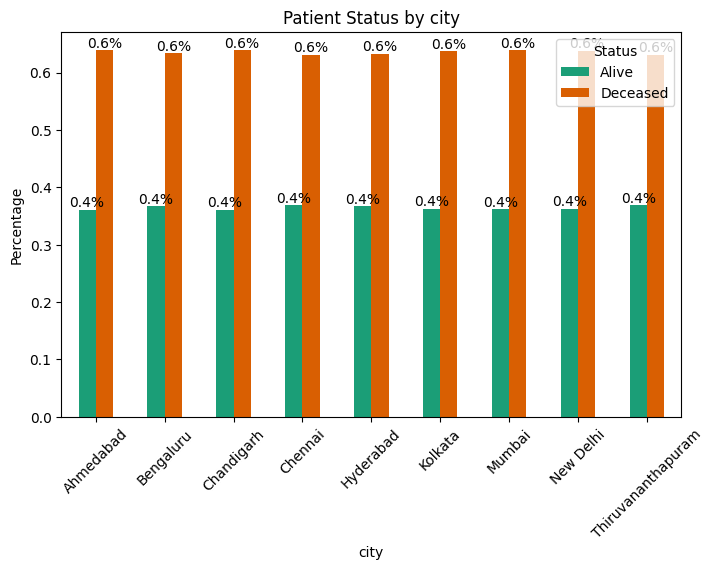

In [93]:
ax = status_pct_by_city.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("city")
plt.title("Patient Status by city")
plt.legend(title="Status")
plt.xticks(rotation=45)
_plt.show()

***◆ just like the state, the city wise survival status is also uniform suggesting this as a weak predictor.dropping this feature later on.***

### <u>Analyzing Patient Status by Hospitals</u>

In [95]:
status_pct_by_Hospital=pd.crosstab(df["Hospital_Name"], df["Status"],normalize="index")
status_pct_by_Hospital

Status,Alive,Deceased
Hospital_Name,,
AIIMS,0.366939,0.633061
Adyar Cancer Institute,0.368611,0.631389
Basavatarakam Indo American Cancer Hospital,0.367223,0.632777
Gujarat Cancer Research Institute,0.361108,0.638892
Kidwai Memorial Institute of Oncology,0.366624,0.633376
PGIMER,0.361298,0.638702
Rajiv Gandhi Cancer Institute,0.357563,0.642437
Regional Cancer Centre,0.368694,0.631306
Tata Medical Center,0.362933,0.637067


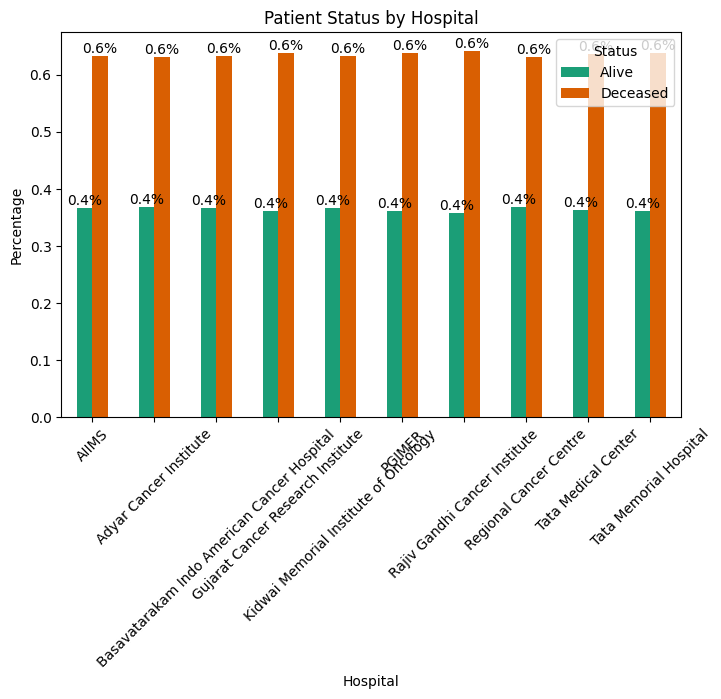

In [97]:
ax = status_pct_by_Hospital.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("Hospital")
plt.title("Patient Status by Hospital")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ survival status is kind of uniform across hospitals.dropping this feature later on***

### <u>How Patient Outcomes Vary Across Treatments</u>

In [98]:
status_pct_by_Treatment_Type=pd.crosstab(df["Treatment_Type"], df["Status"],normalize="index")
status_pct_by_Treatment_Type

Status,Alive,Deceased
Treatment_Type,,
Chemo + Radiation,0.388557,0.611443
Chemotherapy,0.275957,0.724043
Palliative Care,0.238840,0.761160
Radiation,0.450250,0.549750
Surgery,0.535837,0.464163
Surgery + Chemotherapy,0.392593,0.607407
Targeted Therapy,0.295584,0.704416


***◆ Patient results varied across different treatment types.*** 

***◆ Patients who underwent Surgery had the best result, with about 54% alive and 46% deceased.*** 

***◆ Patients receiving Radiation also showed relatively better survival rate, with around 45% alive.***

***◆ On the other hand, patients receiving Palliative Care had the highest mortality rate, with about 76% deceased.*** 

***◆ this trend is also seen among patients treated with Chemotherapy and Targeted Therapy, where around 70–72% of patients were deceased.***

***◆ But this cannot be concluded since the treatment type depends upon cancer_stage.patients with advanced cancer_stages have higher mortalilty rate compared to early detection where treatment varies.***

***◆ so lets look at how treatment_type varies with cancer_stage.***

In [102]:
treatment_type_by_stage=pd.crosstab(
    df["Stage"],
    df["Treatment_Type"],
    normalize="index"
) * 100
treatment_type_by_stage

Treatment_Type,Chemo + Radiation,Chemotherapy,Palliative Care,Radiation,Surgery,Surgery + Chemotherapy,Targeted Therapy
Stage,,,,,,,
Stage I,0.000000,0.000000,0.000000,19.825983,80.174017,0.000000,0.000000
Stage II,14.360827,13.999599,14.577564,14.469195,14.348786,14.103953,14.140076
Stage III,14.092056,14.511784,14.415360,14.259380,14.148776,14.233856,14.338788
Stage IV,0.000000,30.042797,50.012112,0.000000,0.000000,0.000000,19.945090


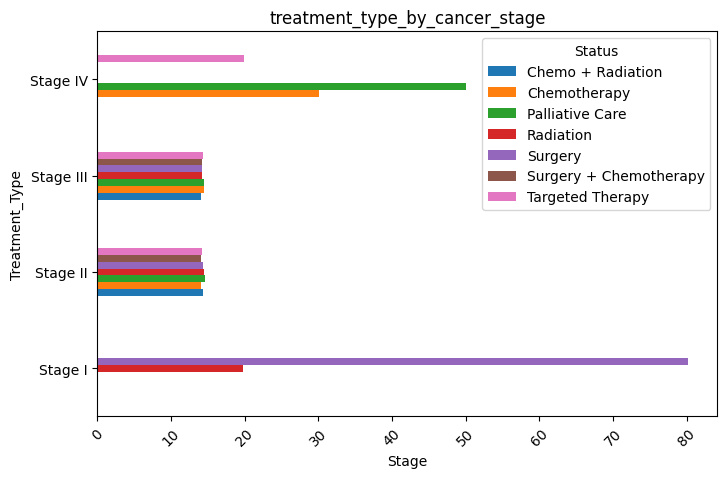

In [104]:
treatment_type_by_stage.plot(
    kind="barh",
    figsize=(8, 5),
)

plt.ylabel("Treatment_Type")
plt.xlabel("Stage")
plt.title("treatment_type_by_cancer_stage")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ This shows treatment_type is heavily dependent of cancer_stage.there is a possible multi colinearity among these two.will look in to this in detail later on***

### <u>Patient Status and Survival Duration</u>

In [135]:
df["Month_Group"] = pd.cut(
    df["Survival_Months"],
    bins=[0, 12, 24, 36, 48, 60],
    labels=["0-12", "12-24", "24-36", "36-48", "48-60"],
    include_lowest=True
)



Month_Group
0-12     36.848
12-24    27.106
24-36    18.626
36-48    12.978
48-60     4.442
Name: proportion, dtype: float64

In [137]:
month_pct=pd.crosstab(df["Month_Group"], df["Status"],normalize="index")
month_pct

Status,Alive,Deceased
Month_Group,,
0-12,0.137321,0.862679
12-24,0.332288,0.667712
24-36,0.493504,0.506496
36-48,0.701649,0.298351
48-60,0.913552,0.086448


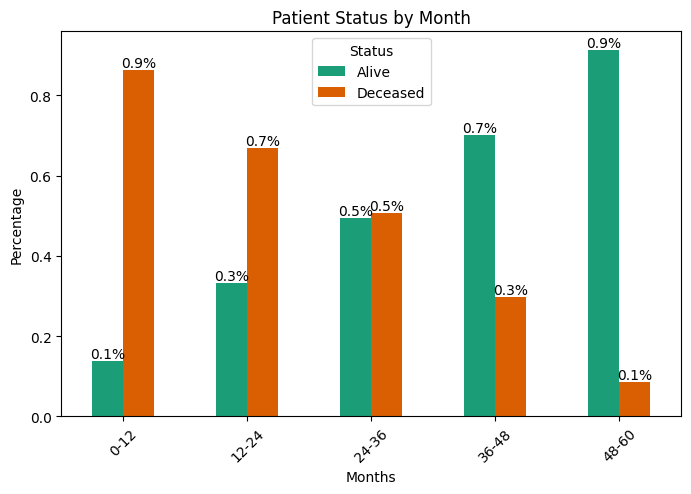

In [138]:
ax = month_pct.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1b9e77", "#d95f02"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Percentage")
plt.xlabel("Months")
plt.title("Patient Status by Month")
plt.legend(title="Status")
plt.xticks(rotation=45)
plt.show()

***◆ A strong relationship was observed between survival duration and patient status.*** 

***◆ Patients with shorter survival durations (0–12 months) had the highest mortality rates,*** 

***◆ whereas those who have survival durations 48–60 months had the highest probability of being alive.***

***◆ but if we include this feature for predicting survival status there is high probability that the model learn from this feature instead of other features***

***◆ survival duration may cause target leakage so not using this for prediction.***


### <u>Patient Status and Diagnosis_Date</u>

In [141]:
df["Diagnosis_Date"].dtype

dtype('O')

In [142]:
df["Diagnosis_Date"] = pd.to_datetime(df["Diagnosis_Date"])

In [143]:
df["Diagnosis_Date"].describe()

count                           100000
mean     2023-12-31 02:14:44.447999744
min                2022-01-01 00:00:00
25%                2022-12-31 00:00:00
50%                2024-01-01 00:00:00
75%                2024-12-30 00:00:00
max                2026-01-01 00:00:00
Name: Diagnosis_Date, dtype: object

In [144]:
df["year"]=df["Diagnosis_Date"].dt.year

***◆ creating a year column just to analyze whether there is a yearly trend in no.of cases appeared***

In [145]:
year_pct=pd.crosstab(df["year"], df["Status"],normalize="index")
year_pct

Status,Alive,Deceased
year,,
2022,0.368471,0.631529
2023,0.363272,0.636728
2024,0.363187,0.636813
2025,0.361910,0.638090
2026,0.387097,0.612903


In [147]:
pd.crosstab(df["year"], df["Status"])

Status,Alive,Deceased
year,,
2022,9235,15828
2023,9052,15866
2024,9116,15984
2025,8996,15861
2026,24,38


***◆ The survival status of patient is uniform from 2022-25 with one-third of patients being alive and two-thirds being deceased each year. Although 2026 showed a slightly higher proportion of surviving patients, this year contained only 62 records, making it difficult to draw meaningful conclusions
so this feature is not included for status prediction***

In [213]:
df_selected=df[["Age","Gender","Cancer_Type","Stage","Treatment_Type"]]

***◆ The features which is strong predictor are kept while other features has been dropped which is of weak prediction or the features which may introduce multi collinearity***

In [214]:
df_selected.head()

,Age,Gender,Cancer_Type,Stage,Treatment_Type
0,82,Female,Stomach Cancer,Stage III,Palliative Care
1,45,Female,Cervical Cancer,Stage IV,Palliative Care
2,47,Male,Oral Cancer,Stage III,Targeted Therapy
3,1,Female,Leukemia,Stage II,Palliative Care
4,52,Female,Cervical Cancer,Stage IV,Palliative Care


### <u>One Hot Encoding</u>

In [215]:
df_encoded=pd.get_dummies(df_selected,drop_first=True)
df_encoded

,Age,Gender_Male,Cancer_Type_Cervical Cancer,Cancer_Type_Colorectal Cancer,Cancer_Type_Leukemia,Cancer_Type_Lung Cancer,Cancer_Type_Oral Cancer,Cancer_Type_Ovarian Cancer,Cancer_Type_Prostate Cancer,Cancer_Type_Stomach Cancer,Stage_Stage II,Stage_Stage III,Stage_Stage IV,Treatment_Type_Chemotherapy,Treatment_Type_Palliative Care,Treatment_Type_Radiation,Treatment_Type_Surgery,Treatment_Type_Surgery + Chemotherapy,Treatment_Type_Targeted Therapy
0,82,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False
1,45,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False
2,47,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
3,1,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
4,52,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,50,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
99996,32,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
99997,92,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False
99998,60,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False


***◆ Encoded the features using one hot encoding***

### <u>VIF calculation</u>

In [216]:
df_encoded = df_encoded.astype(float)

***The VIF values remain below the commonly used threshold of 5, indicating that the association is moderate rather than problematic.***

In [217]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = add_constant(df_encoded)
vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df)

                                  Feature        VIF
0                                   const  44.515852
1                                     Age   1.251676
2                             Gender_Male   1.879786
3             Cancer_Type_Cervical Cancer   1.288666
4           Cancer_Type_Colorectal Cancer   1.360790
5                    Cancer_Type_Leukemia   1.236140
6                 Cancer_Type_Lung Cancer   1.660328
7                 Cancer_Type_Oral Cancer   1.772759
8              Cancer_Type_Ovarian Cancer   1.100449
9             Cancer_Type_Prostate Cancer   1.689344
10             Cancer_Type_Stomach Cancer   1.408519
11                         Stage_Stage II   3.023454
12                        Stage_Stage III   3.431342
13                         Stage_Stage IV   4.100756
14            Treatment_Type_Chemotherapy   2.652820
15         Treatment_Type_Palliative Care   3.205898
16               Treatment_Type_Radiation   2.179317
17                 Treatment_Type_Surgery   3.

### <u>Heatmap visualization</u>

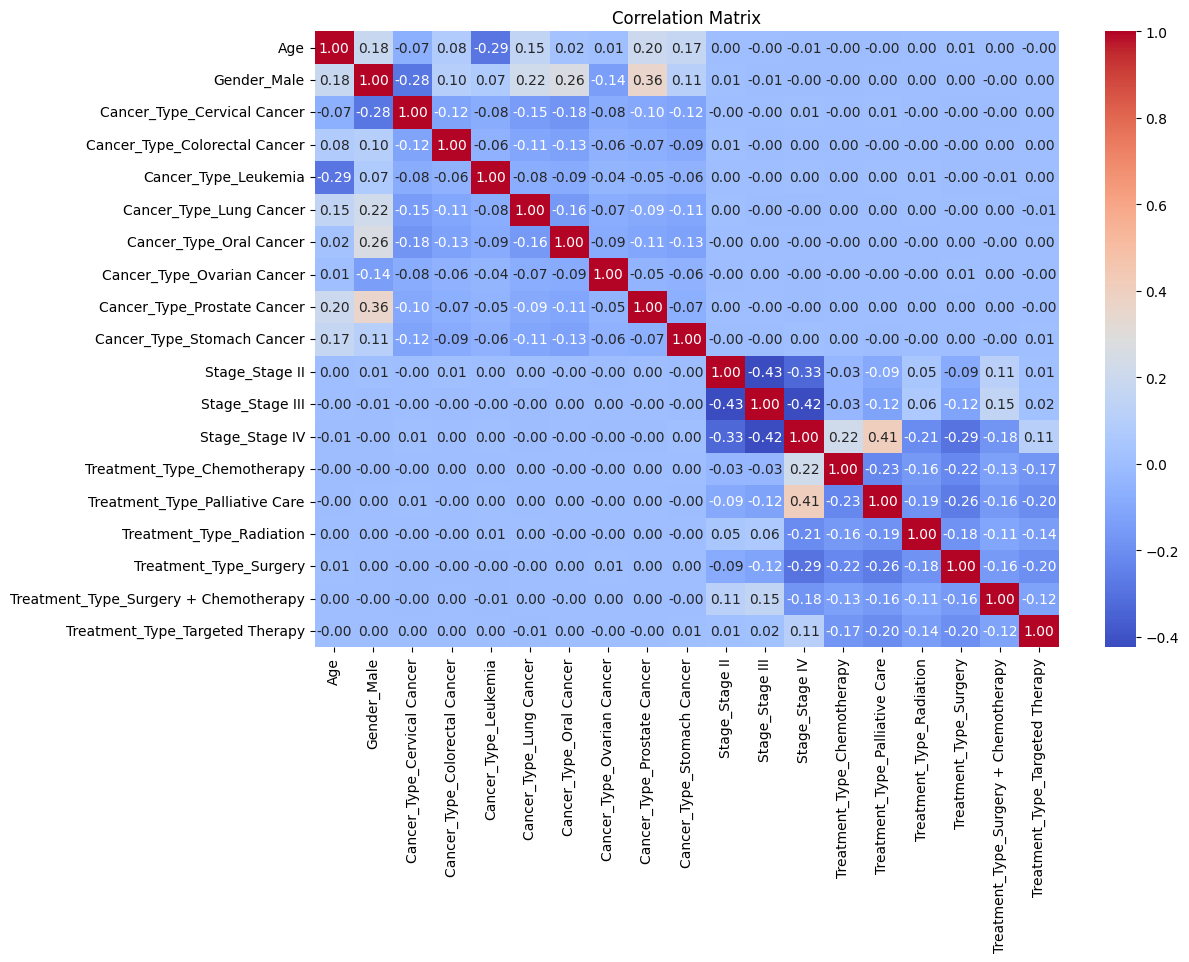

In [218]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [219]:
X_target = df_encoded.copy()
X_target["Status_binary"] = df["Status"].map({
    "Alive": 0,
    "Deceased": 1
})

corr_matrix = X_target.corr()

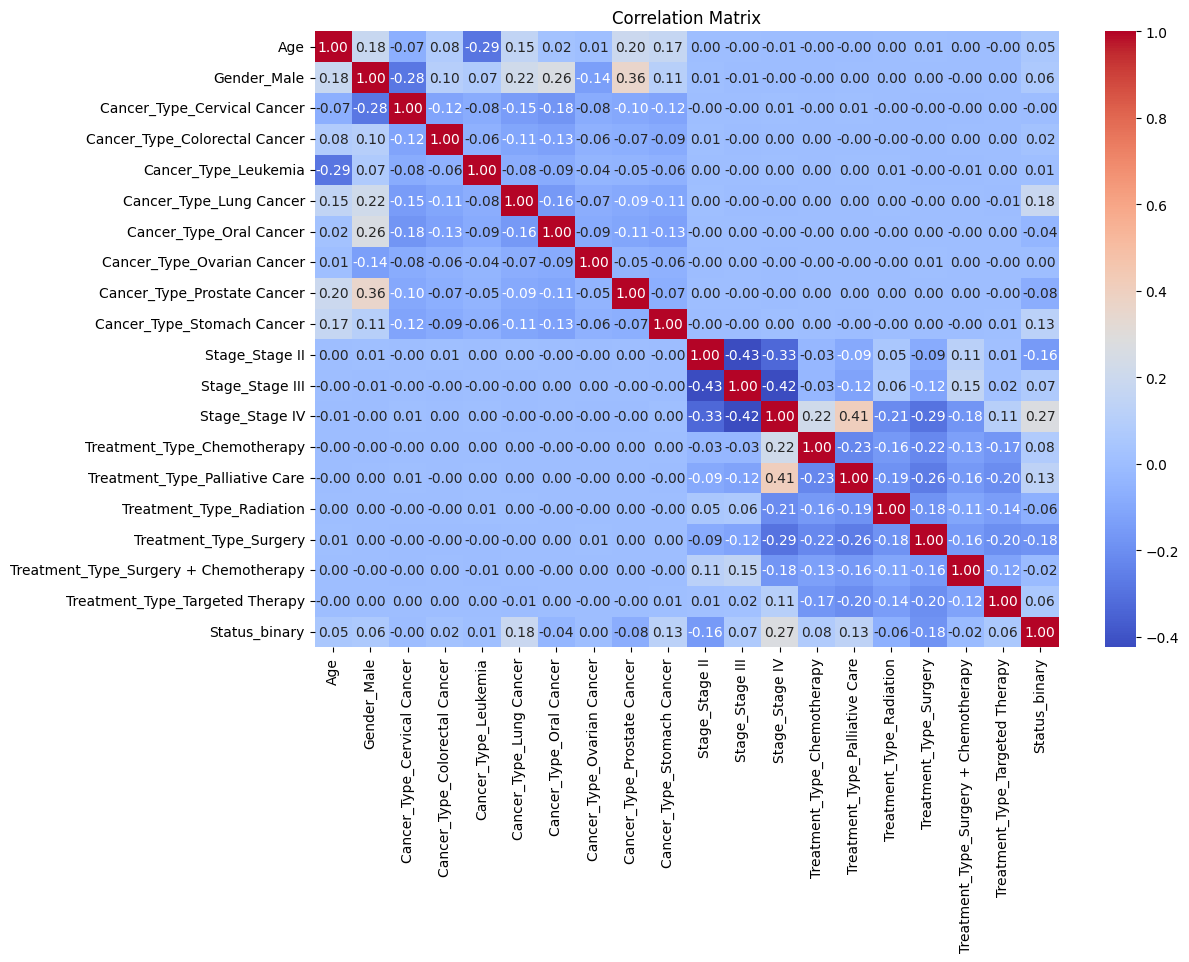

In [220]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [221]:
X=df_encoded.copy()
y = df["Status"].map({
    "Alive": 0,
    "Deceased": 1
})

### <u>Train test split</u>

In [222]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [223]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 19)
(20000, 19)
(80000,)
(20000,)


***◆ Since this is an imbalanced dataset .thought of using strartification in train test split***

## <u>Model Selection and Training</u>

#### <u>LogisticRegression<u/>

In [224]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(random_state=42)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"],
    "max_iter": [1000],
    
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
0.7960318876987034


***◆ LogisticRegression produced an F1-score of 0.796 from 5-fold cross-validation***

#### <u>RandomForest</u>

In [225]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
0.7399643832019374


***◆ RandomForestClassifier produced an F1-score of 0.74 from 5-fold cross-validation.***

***◆ Logistic regression is taking the lead with the score of 0.796***

#### <u>Xgboost</u>

In [226]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}      

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)

{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [227]:
print(search.best_score_)

0.7998797703046548


***◆ Xgboost has the best f1 score so far about 0.799***

***◆ But the difference of f1 score from logistic regression is only about  0.0039 which is not such a great difference***

***◆ So both the xgboost and logistic regression performed similarly well on this dataset.***    


In [230]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

lgbm = LGBMClassifier(
    random_state=42
)

scores = cross_val_score(
    lgbm,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Fold Scores:", scores)
print("Mean F1:", scores.mean())

Fold Scores: [0.7918341  0.79701929 0.79791743 0.8025061  0.7957296 ]
Mean F1: 0.7970013058401679


***light gbm also provided a good performance with f1 score of 0.797***

#### ⭐<u> Note: <u/>


**◆ The aim of this project was to find patients who may be at a higher risk .**

**◆ XGBoost performed slightly better than the other models, so it was selected as the final model.** 

**◆ Although Logistic Regression achieved almost the same results, XGBoost was better at capturing complex patterns in the data.**

**◆ focused on recall because, in medical settings, it is usually better to mark a few extra patients as high risk than to miss someone who needs        closer monitoring .**

### <u>Final model</u>

In [232]:
model_xgb= XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.01,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric="logloss"
)

In [235]:
y_pred=model_xgb.predict(X_test)
y_pred

array([1, 0, 0, ..., 1, 0, 1], shape=(20000,))

In [233]:
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

### <u>Threshold tuning</u>

In [237]:
y_proba=model_xgb.predict_proba(X_test)
y_proba

array([[0.47303176, 0.52696824],
       [0.56700706, 0.43299296],
       [0.5104134 , 0.4895866 ],
       ...,
       [0.2394507 , 0.7605493 ],
       [0.56700706, 0.43299296],
       [0.1810174 , 0.8189826 ]], shape=(20000, 2), dtype=float32)

In [239]:
y_prob_deceased = model_xgb.predict_proba(X_test)[:, 1]

In [240]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7971747915680635


In [241]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.48      0.56      7285
           1       0.74      0.86      0.80     12715

    accuracy                           0.72     20000
   macro avg       0.70      0.67      0.68     20000
weighted avg       0.71      0.72      0.71     20000



In [257]:
from sklearn.metrics import recall_score,precision_score

for t in np.arange(0.1, 0.91, 0.05):
    y_pred = (y_prob_deceased >= t).astype(int)
    print(
        f"Threshold: {t:.2f} | "
        f"Precision: {precision_score(y_test, y_pred):.3f} | "
        f"Recall: {recall_score(y_test, y_pred):.3f} | "
        f"F1: {f1_score(y_test, y_pred):.3f}"
    )

Threshold: 0.10 | Precision: 0.636 | Recall: 1.000 | F1: 0.777
Threshold: 0.15 | Precision: 0.636 | Recall: 1.000 | F1: 0.777
Threshold: 0.20 | Precision: 0.636 | Recall: 1.000 | F1: 0.777
Threshold: 0.25 | Precision: 0.636 | Recall: 1.000 | F1: 0.777
Threshold: 0.30 | Precision: 0.636 | Recall: 1.000 | F1: 0.777
Threshold: 0.35 | Precision: 0.641 | Recall: 0.999 | F1: 0.781
Threshold: 0.40 | Precision: 0.672 | Recall: 0.971 | F1: 0.795
Threshold: 0.45 | Precision: 0.688 | Recall: 0.952 | F1: 0.798
Threshold: 0.50 | Precision: 0.742 | Recall: 0.861 | F1: 0.797
Threshold: 0.55 | Precision: 0.755 | Recall: 0.829 | F1: 0.790
Threshold: 0.60 | Precision: 0.763 | Recall: 0.803 | F1: 0.782
Threshold: 0.65 | Precision: 0.823 | Recall: 0.625 | F1: 0.711
Threshold: 0.70 | Precision: 0.856 | Recall: 0.512 | F1: 0.641
Threshold: 0.75 | Precision: 0.865 | Recall: 0.435 | F1: 0.579
Threshold: 0.80 | Precision: 0.943 | Recall: 0.093 | F1: 0.169
Threshold: 0.85 | Precision: 0.000 | Recall: 0.000 | F1

C:\Users\najee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\najee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### ⭐<u> Note: <u/>

***◆ By default, the model uses a threshold of 0.50 to classify patients as high-risk or low-risk.***

***◆ Lowering The threshold to 0.45 helped the model identify more high-risk patients.*** 

***◆ The recall improved from 86.1% to 95.2%, which means fewer high-risk patients were missed.***
    
***◆ Although this led to some false alarms, the overall F1-score remained almost the same.***
    
***◆ Since the main goal of this project was to identify patients who are at higher risk.I consider lowering threshold to 0.45 as a better choice to make.*** 

In [ ]:
y_pred_new = (y_prob_deceased >= 0.45).astype(int)


In [264]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))

Precision: 0.6877167055078725
Recall: 0.9515532835233975
F1: 0.7984030618978487


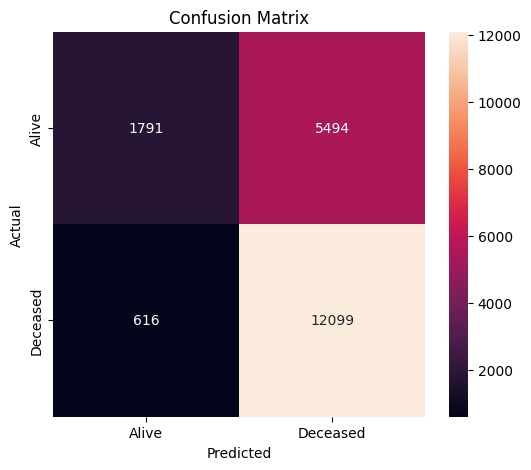

In [272]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,      
    fmt="d",         
    xticklabels=["Alive", "Deceased"],
    yticklabels=["Alive", "Deceased"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

***◆ The model was very effective at identifying patients who were truly at high risk, correctly detecting about 95% of them.***

***◆Although it also flagged some lower-risk patients as high-risk, this trade-off was considered acceptable because the main objective was to reduce the number of high-risk patients who were missed by the model..***

### <u>Feature Importance Visualization</u>

In [274]:

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                          Feature  Importance
12                 Stage_Stage IV    0.530360
11                Stage_Stage III    0.276047
5         Cancer_Type_Lung Cancer    0.091336
9      Cancer_Type_Stomach Cancer    0.055583
10                 Stage_Stage II    0.018117
3   Cancer_Type_Colorectal Cancer    0.006596
2     Cancer_Type_Cervical Cancer    0.006327
8     Cancer_Type_Prostate Cancer    0.005813
4            Cancer_Type_Leukemia    0.002790
6         Cancer_Type_Oral Cancer    0.002784


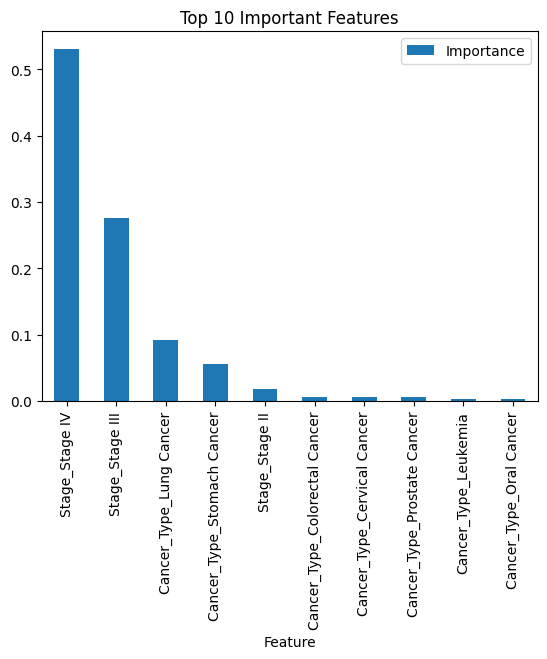

In [248]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.show()

 ***◆ stage IV and stage III features contributed the highest***

### <u>Exporting file using Joblib</u>

In [284]:
import joblib

joblib.dump(model_xgb,"xgb_cancer_risk_model.pkl")

['xgb_cancer_risk_model.pkl']

In [278]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [279]:
threshold = 0.45

joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']

### <u>Conclusion</u>


***➤ This project demonstrated that machine learning can be used to identify patients who may be at a higher risk of mortality.***

***➤ After exploring multiple models, XGBoost was selected as the final model XGBoost performed slightly better than the rest of the models***

***➤ By adjusting the prediction threshold, I was able to identify more high-risk patients without changing the model itself. Lowering the threshold helped the model catch around 95% of patients who were truly at higher risk.***

***➤ Therefore, a model that prioritizes identifying patients who may need closer monitoring can provide meaningful support to clinicians.***

***➤ In the end, this project showed me that machine learning in healthcare is not just about building accurate models. It is about understanding the trade-offs, choosing the right evaluation metrics, and making decisions that support the real-world objective.***



***<span style="color:red"> Disclaimer:</span>***

This project is intended for educational purposes only and should not be used as a substitute for professional medical advice or clinical decision-making.